In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# Проверяем, запускался ли уже этот блок
if "IS_ROOT_SET" not in globals():
    project_root = Path.cwd().parent.parent
    os.chdir(project_root)

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    # Создаем флаг-индикатор
    IS_ROOT_SET = True
    print("Корневая директория инициализирована.")
else:
    print("Инициализация уже была выполнена ранее.")

Корневая директория инициализирована.


In [18]:
from mmdet.apis import init_detector, inference_detector
from mmdet.registry import VISUALIZERS
import mmcv

In [9]:
config_file = "src/mmdetection/configs/fcos_minecraft.py"
checkpoint_file = (
    "src/artifacts/checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth"
)

In [ ]:
model = init_detector(config_file, checkpoint_file, device="cpu")

/home/vdavydov/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/__init__.py:169: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  _bootstrap._exec(spec, module)


Loads checkpoint by local backend from path: src/artifacts/checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([17, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([17]).


In [ ]:
input_image = (
    "datasets/minecraft/test/image11_png_jpg.rf.64ae384b4756d555a3753877a81e1b04.jpg"
)
output_dir = "src/artifacts/inference"
os.makedirs(output_dir, exist_ok=True)

In [22]:
result = inference_detector(model, input_image)

In [24]:
import matplotlib.pyplot as plt

/home/vdavydov/projects/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


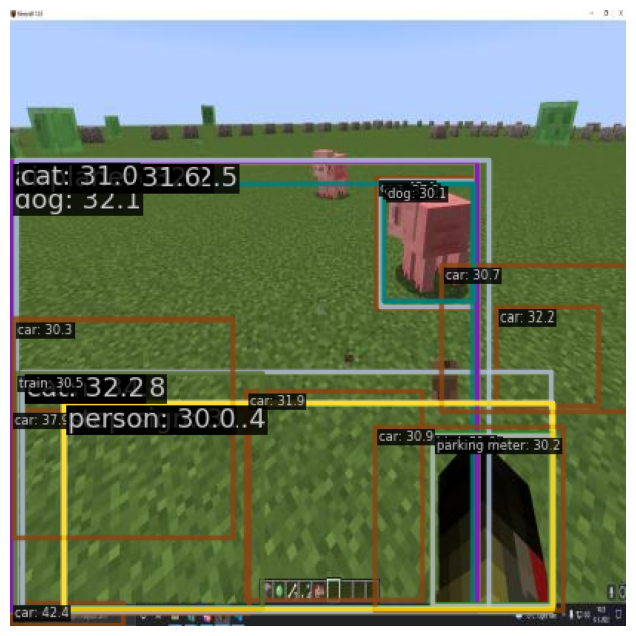

✅ Результат успешно сохранен в: src/artifacts/inference/test_pretrained.jpg


In [26]:
img = mmcv.imread(input_image)
img = mmcv.imconvert(img, "bgr", "rgb")

visualizer = VISUALIZERS.build(model.cfg.visualizer)
visualizer.dataset_meta = model.dataset_meta

visualizer.add_datasample(
    name="result",
    image=img,
    data_sample=result,
    draw_gt=False,
    pred_score_thr=0.3,
    show=False,
)

result_img = visualizer.get_image()

plt.figure(figsize=(12, 8))
plt.imshow(result_img)
plt.axis("off")
plt.show()

output_file = os.path.join(output_dir, "test_pretrained.jpg")
mmcv.imwrite(mmcv.imconvert(result_img, "rgb", "bgr"), output_file)
print(f"✅ Результат успешно сохранен в: {output_file}")